In [ ]:
!pip install matplotlib

In [ ]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cat.png -O cat.png
!wget https://i.pinimg.com/736x/2c/fd/9f/2cfd9fa452a0a48945a3821405bbe711.jpg -O lenna.jpg
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/baboon.png -O baboon.png

--2026-10-02 13:48:51--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cat.png
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 663451 (648K) [image/png]
Saving to: ‘cat.png’

cat.png             100%[===================>] 647.90K  3.01MB/s    in 0.2s    

2026-10-02 13:48:52 (3.01 MB/s) - ‘cat.png’ saved [663451/663451]

--2026-10-02 13:48:52--  https://i.pinimg.com/736x/2c/fd/9f/2cfd9fa452a0a48945a3821405bbe711.jpg
Resolving i.pinimg.com (i.pinimg.com)... 151.101.0.84, 151.101.64.84, 151.101.128.84, ...
Connecting to i.pinimg.com (i.pinimg.com)|151.101.0.84|:443... connected.

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

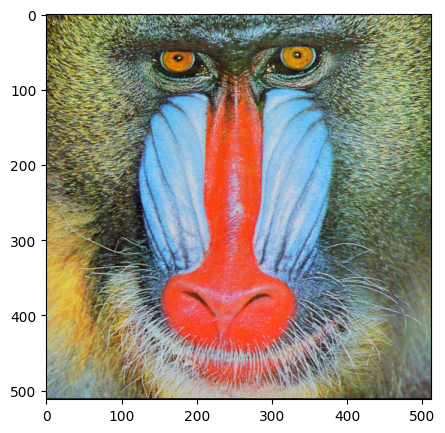

In [ ]:
baboon = np.array(Image.open('baboon.png'))
plt.figure(figsize=(5,5))
plt.imshow(baboon )
plt.show()

In [ ]:
A = baboon

In [ ]:
id(A) == id(baboon)

True

In [ ]:
B = baboon.copy()
id(B)==id(baboon)

False

In [ ]:
baboon[:,:,] = 0

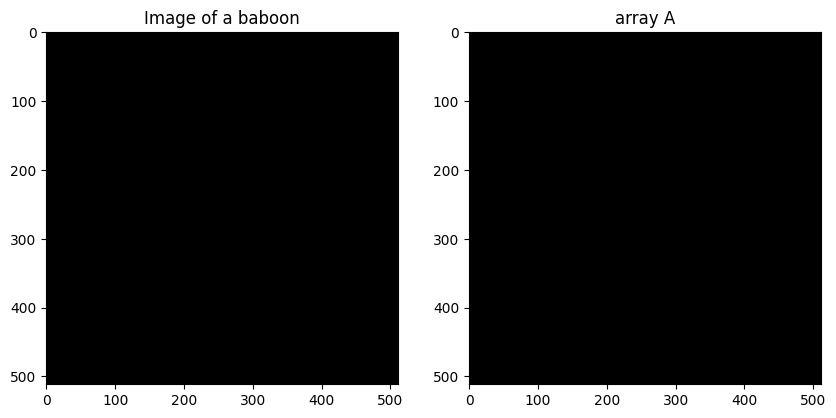

In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(121)
plt.imshow(baboon)
plt.title("Image of a baboon")
plt.subplot(122)
plt.imshow(A)
plt.title("array A")
plt.show()

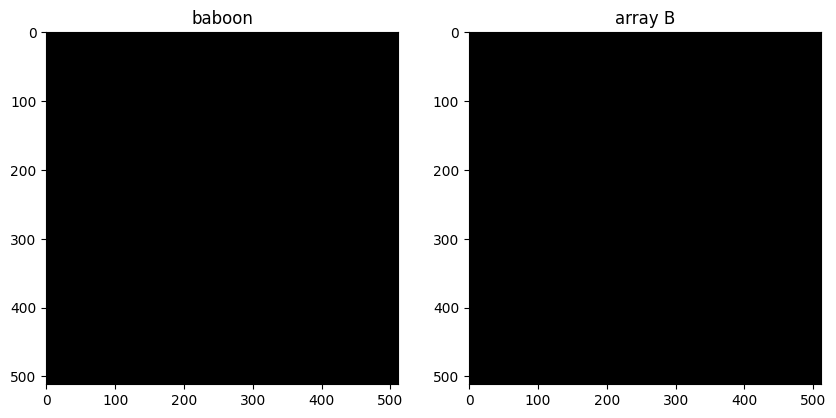

In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(121)
plt.imshow(baboon)
plt.title("baboon")
plt.subplot(122)
plt.imshow(B)
plt.title("array B")
plt.show()

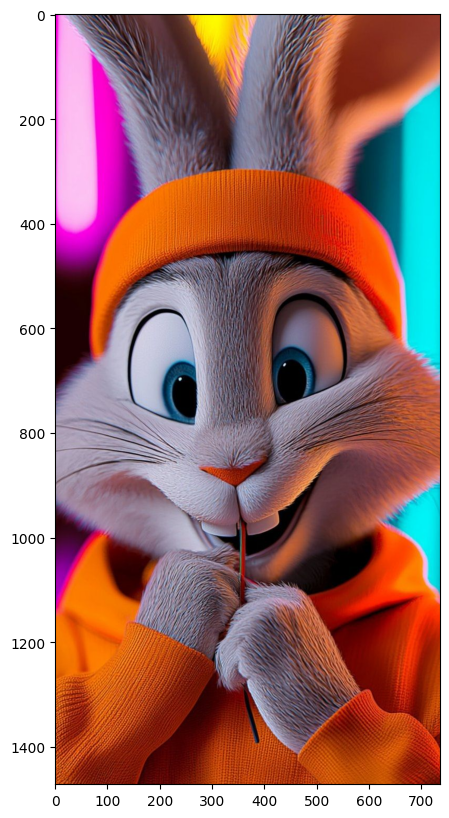

In [ ]:
image = Image.open("lenna.jpg")
plt.figure(figsize=(10,10))
plt.imshow(image)
plt.show()

In [ ]:
array = np.array(image)
width, height, C = array.shape
print(f'width = {width}, height = {height}, C= {C}: ')

width = 1472, height = 736, C= 3: 


In [ ]:
array_flip = np.zeros((width, height, C), dtype=np.uint8)

In [ ]:
for i,row in enumerate(array):
    array_flip[width - 1 - i, :, :] = row

In [ ]:
from PIL import ImageOps

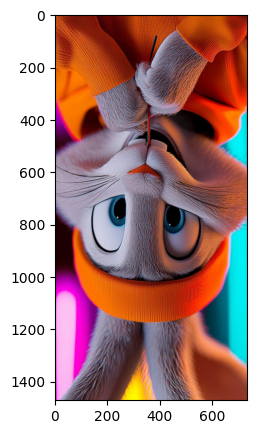

In [ ]:
im_flip = ImageOps.flip(image)
plt.figure(figsize=(5,5))
plt.imshow(im_flip)
plt.show()

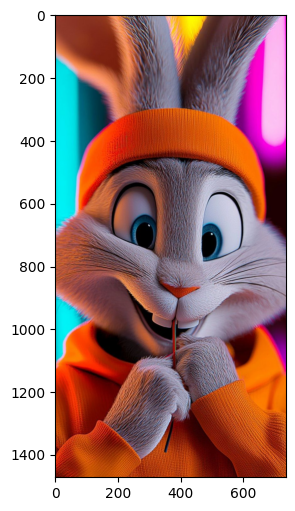

In [ ]:
im_mirror = ImageOps.mirror(image)
plt.figure(figsize=(6,6))
plt.imshow(im_mirror)
plt.show()

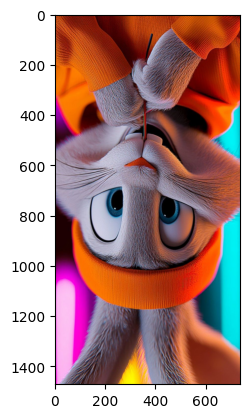

In [ ]:
im_flip = image.transpose(1)
plt.imshow(im_flip)
plt.show()

In [ ]:
flip = {"FLIP_LEFT_RIGHT": Image.FLIP_LEFT_RIGHT,
        "FLIP_TOP_BOTTOM": Image.FLIP_TOP_BOTTOM,
        "ROTATE_90": Image.ROTATE_90,
        "ROTATE_180": Image.ROTATE_180,
        "ROTATE_270": Image.ROTATE_270,
        "TRANSPOSE": Image.TRANSPOSE,
        "TRANSVERSE": Image.TRANSVERSE}

In [ ]:
flip["FLIP_LEFT_RIGHT"]

0

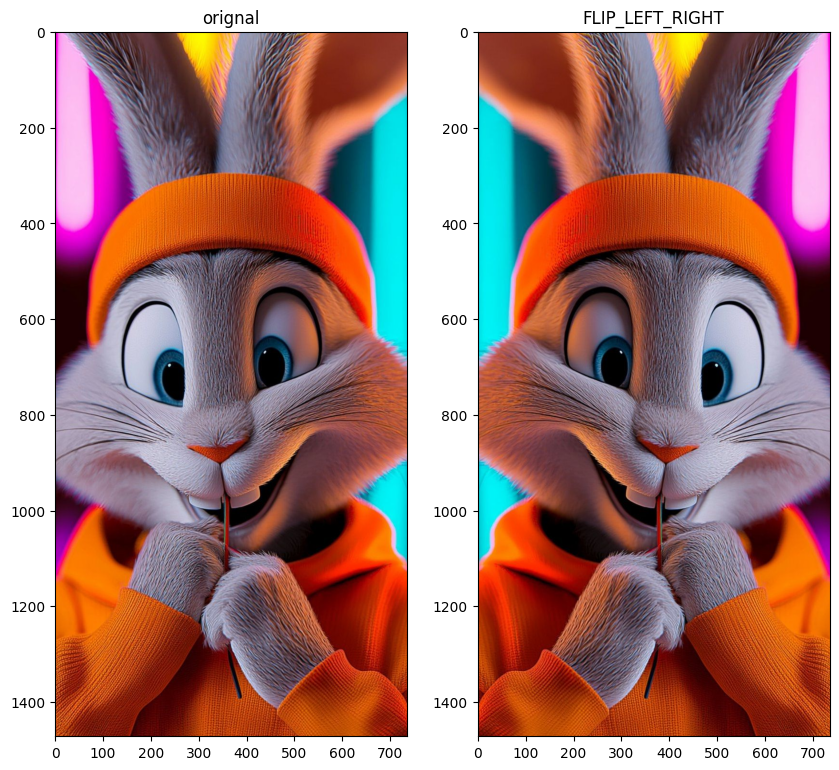

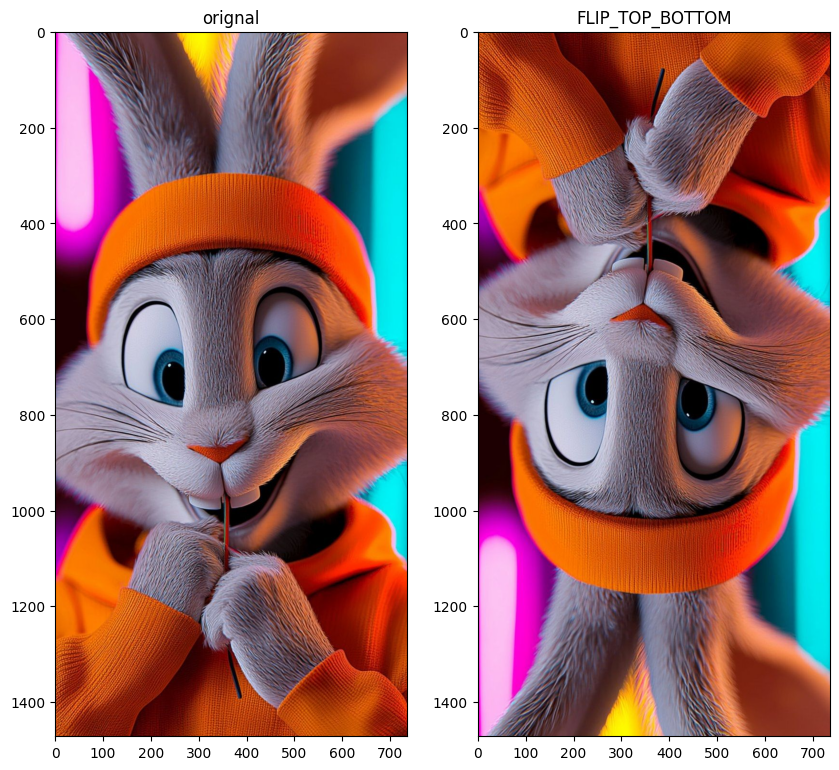

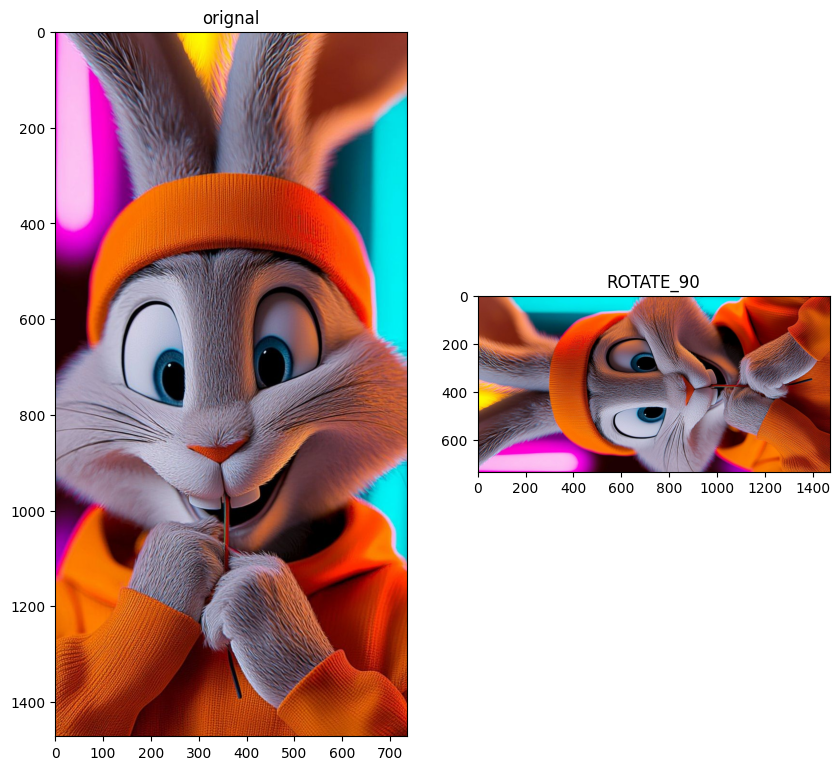

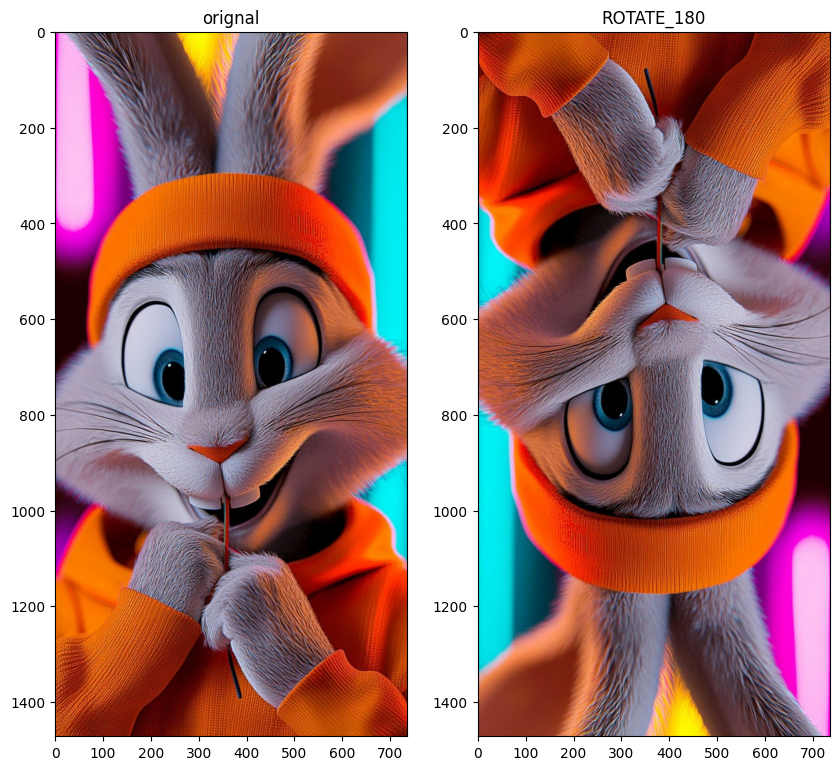

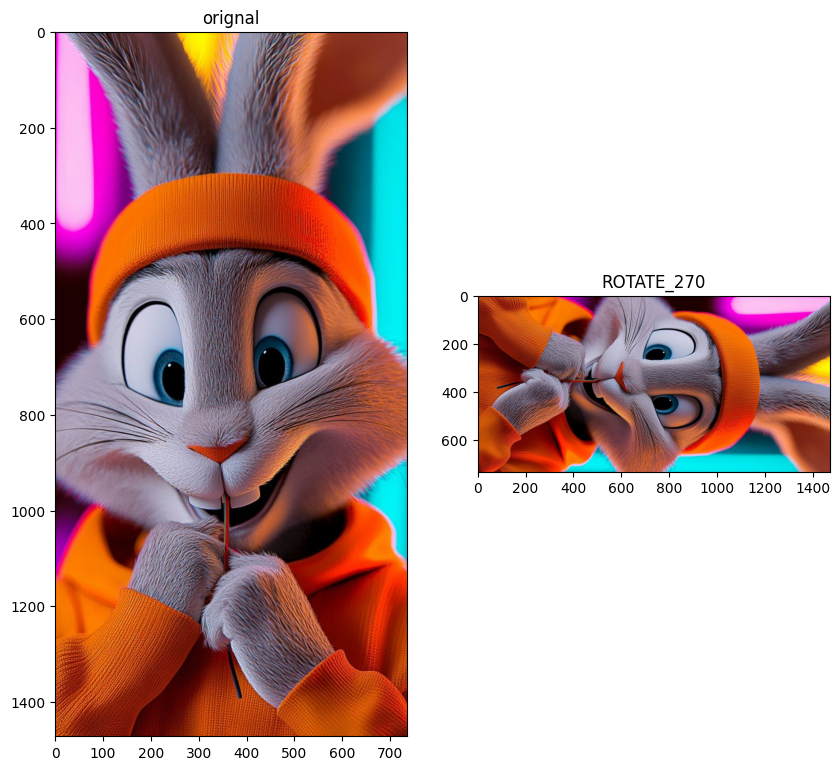

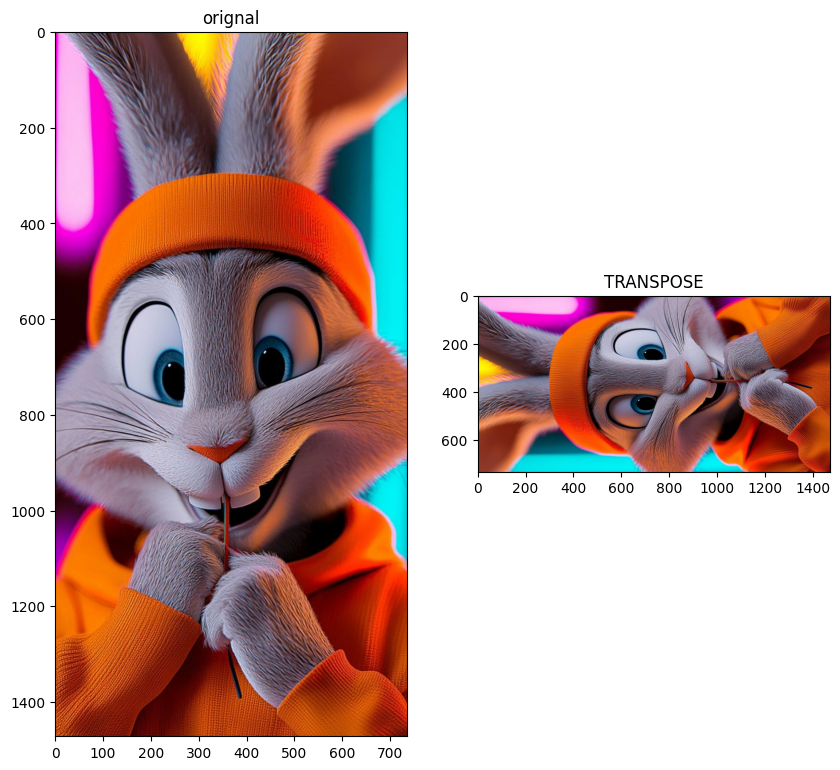

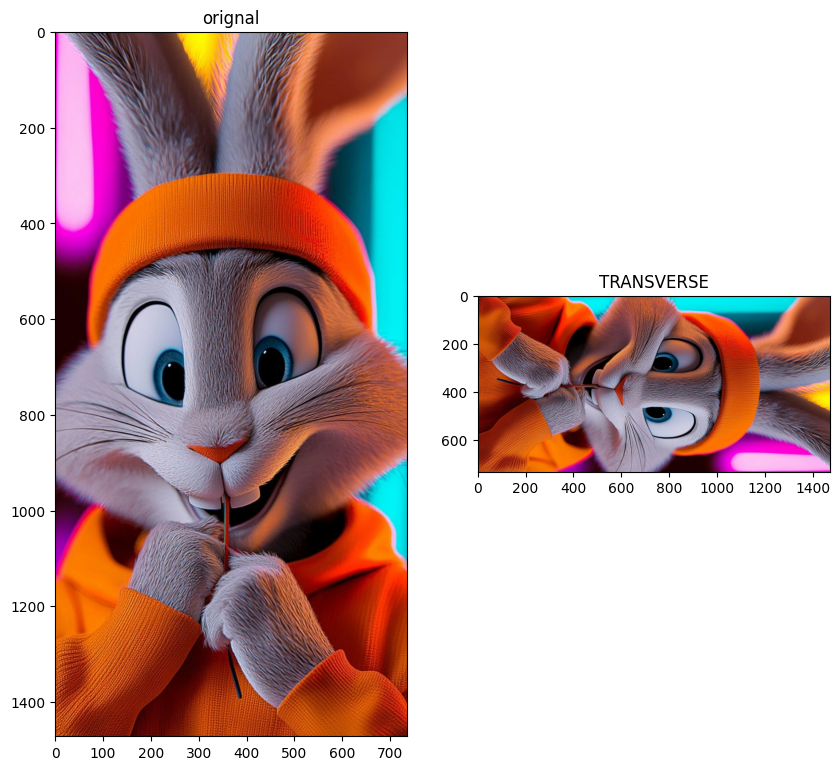

In [ ]:
for key, values in flip.items():
    plt.figure(figsize=(10,10))
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("orignal")
    plt.subplot(1,2,2)
    plt.imshow(image.transpose(values))
    plt.title(key)
    plt.show()

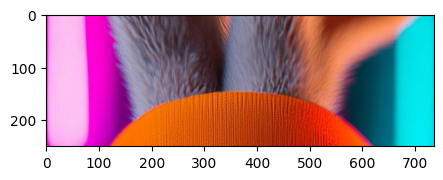

In [ ]:
upper = 150
lower = 400
crop_top = array[upper: lower,:,:]
plt.figure(figsize=(5,5))
plt.imshow(crop_top)
plt.show()

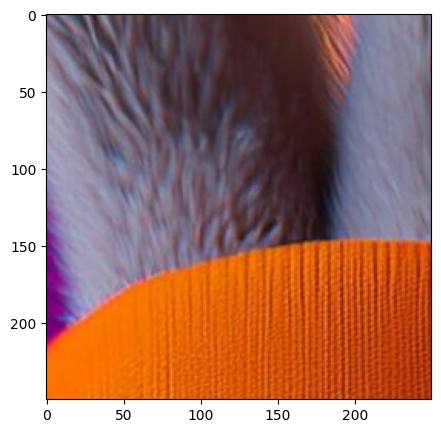

In [ ]:
left = 150
right = 400
crop_horizontal = crop_top[: ,left:right,:]
plt.figure(figsize=(5,5))
plt.imshow(crop_horizontal)
plt.show()

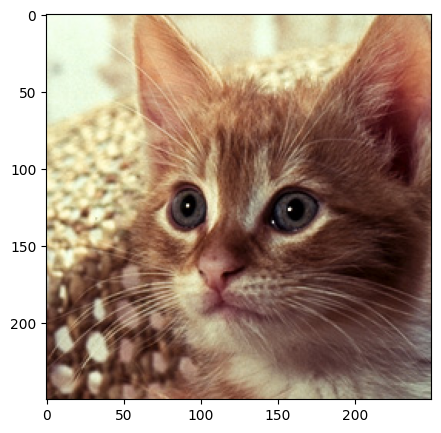

In [ ]:
image = Image.open("cat.png")
crop_image = image.crop((left, upper, right, lower))
plt.figure(figsize=(5,5))
plt.imshow(crop_image)
plt.show()

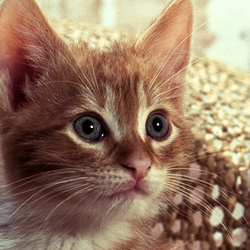

In [ ]:
crop_image = crop_image.transpose(Image.FLIP_LEFT_RIGHT)
crop_image

In [ ]:
array_sq = np.copy(array)
array_sq[upper:lower, left:right, 1:3] = 0

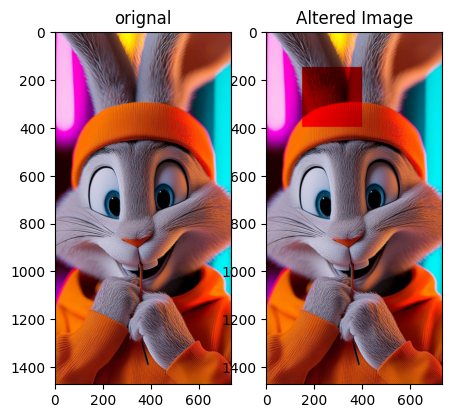

In [ ]:
plt.figure(figsize=(5,5))
plt.subplot(1,2,1)
plt.imshow(array)
plt.title("orignal")
plt.subplot(1,2,2)
plt.imshow(array_sq)
plt.title("Altered Image")
plt.show()

In [ ]:
from PIL import ImageDraw

In [ ]:
image_draw = image.copy()

In [ ]:
image_fn = ImageDraw.Draw(im=image_draw)

In [ ]:
shape = [left, upper, right, lower]
image_fn.rectangle(xy=shape,fill="red")

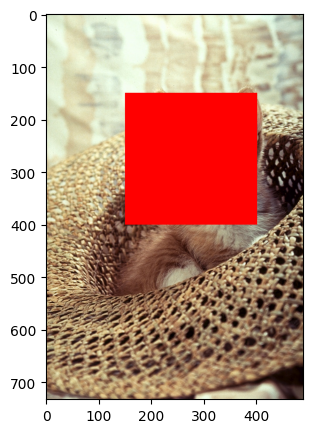

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(image_draw)
plt.show()

In [ ]:
from PIL import ImageFont

In [ ]:
image_fn.text(xy=(0,0),text="box",fill=(0,0,0))

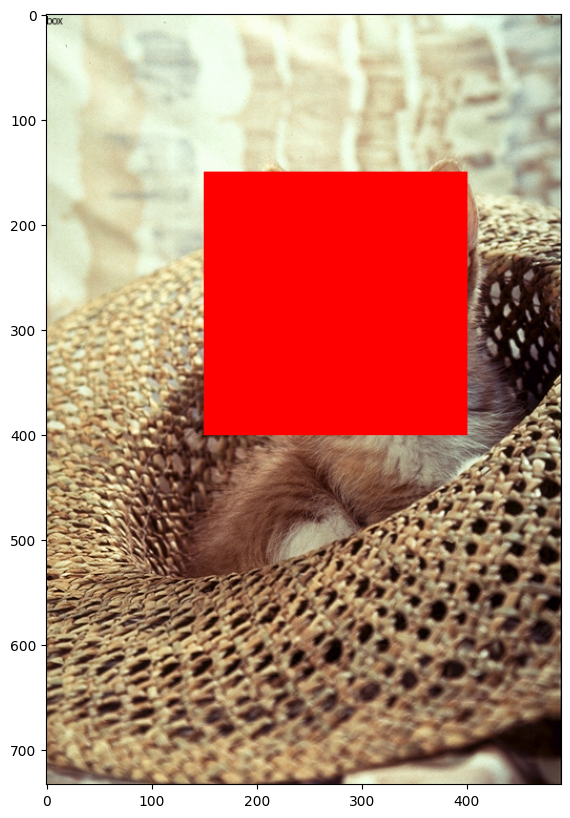

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(image_draw)
plt.show()

In [ ]:
image_lenna = Image.open("lenna.jpg")
array_lenna = np.array(image_lenna)

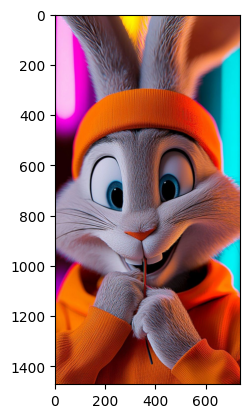

In [ ]:
array_lenna[upper:lower,left:right,:]=array[upper:lower,left:right,:]
plt.imshow(array_lenna)
plt.show()

In [ ]:
image_lenna.paste(crop_image, box=(left,upper))

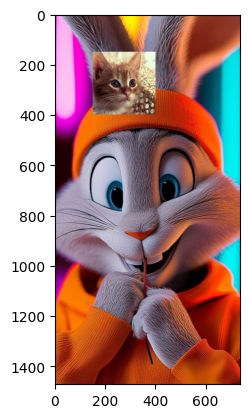

In [ ]:
plt.imshow(image_lenna)
plt.show()

In [ ]:
image = Image.open("cat.png")
new_image=image
copy_image=image.copy()

In [ ]:
id(image)==id(new_image)

True

In [ ]:
id(image)==id(copy_image)

False

In [ ]:
image_fn= ImageDraw.Draw(im=image)
image_fn.text(xy=(0,0),text="box",fill=(0,0,0))
image_fn.rectangle(xy=shape,fill="red")

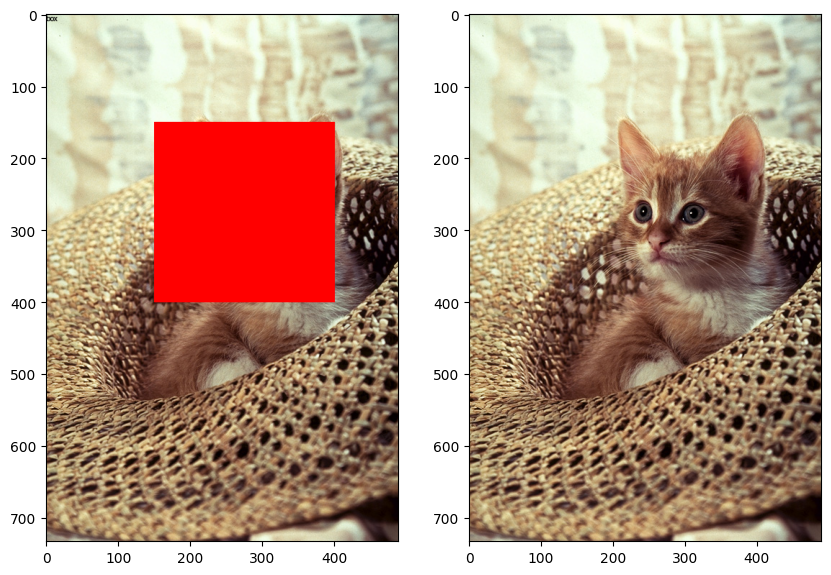

In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(121)
plt.imshow(new_image)
plt.subplot(122)
plt.imshow(copy_image)
plt.show()